# Lecture 38. 에라토스테네스의 체

## 0. 목차
1. 다수의 소수 판별
2. 에라토스테네스의 체 알고리즘
3. 에라토스테네스의 체 알고리즘 동작 예시
4. 에라토스테네스의 체 알고리즘: 소스코드
5. 에라토스테네스의 체 알고리즘 성능 분석
6. 피드백 - Gemini
7. 정리 및 회고


## 1. 다수의 소수 판별

- 37강에서 하나에 대해서 소수인지 판별하는 방법을 다루었다.
- 특정한 수의 범위 안에 존재하는 모든 소수를 찾아야 할 때는 에라토스테네스의 체 알고리즘을 사용할 수 있다.

## 2. 에라토스테네스의 체 알고리즘

- 에라토스테네스의 체 알고리즘은 다수의 자연수에 대하여 소수 여부를 판별할 때 사용하는 대표적인 알고리즘이다.
- 에라토스테네스의 체는 N보다 작거나 같은 모든 소수를 찾을 때 사용할 수 있다.
- 에라토스테네스의 체 알고리즘의 구체적인 동작 과정은 다음과 같다.
1. 2부터 N까지의 모든 자연수를 나열한다.
2. 남은 수 중에서 아직 처리하지 않은 가장 작은 수 i를 찾는다.
3. 남은 수 중에서 i의 배수를 모두 제거한다.(i는 제거하지 않는다.)
4. 더 이상 반복할 수 없을 때까지 2번과 3번의 과정을 반복한다.

## 3. 에라토스테네스의 체 알고리즘 동작 예시

[초기 단계] 2부터 26까지의 모든 자연수를 나열한다.(N=26)

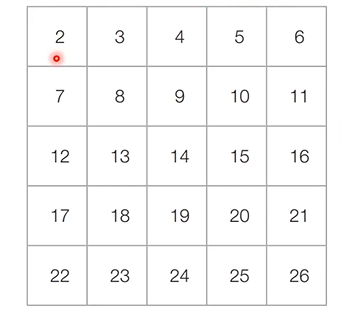

[Step 1] 아직 처리하지 않은 가장 작은 수 2를 제외한 2의 배수는 모두 제거한다.

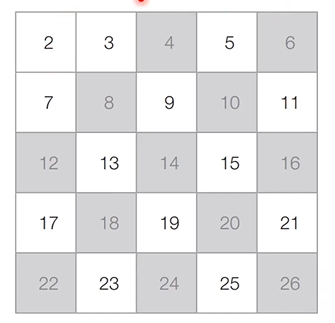

[Step 2] 아직 처리하지 않은 가장 작은 수 3을 제외한 3의 배수는 모두 제거한다.

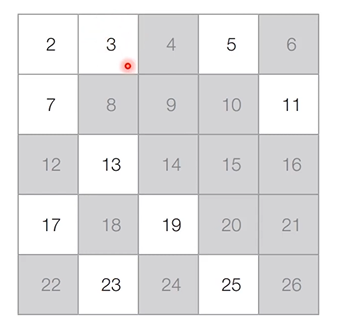

[Step 3] 아직 처리하지 않은 가장 작은 수 5를 제외한 5의 배수는 모두 제거한다.

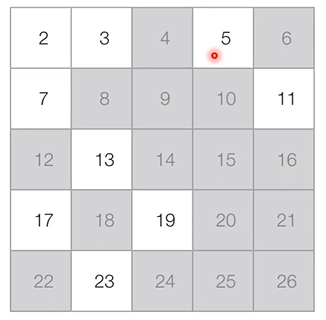

[Step 4] 마찬가지의 과정을 반복했을 때 최정적인 결과는 다음과 같다.

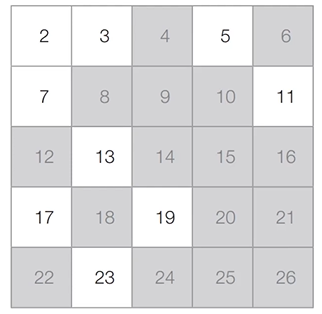

## 4. 에라토스테네스의 체 알고리즘: 소스코드

### 구현 연습

#### 구현 계획

1. N 만큼의 리스트를 준비한다.
2. 1보다 큰 가장 작은 자연수를 찾고 자신을 제외한 배수는 제거한다.
3. 가장 작은 자연수를 찾고 자신을 제외한 배수는 제거한다.
4. 위의 과정을 N보다 작을 동안 반복한다.



In [24]:
n = int(input())
num = [0]
for i in range(1, n+1):
    num.append(i)

m = 2
while n > m:
    q = n // m
    for i in range(2, q+1):
        num[m*i] = 0
    
    for i in range(m+1, n+1):
        if num[i] != 0:
            m = i
            break
    if m == n:
        break
        
        
prime_num = list(set(num))
print(prime_num[2:])

[2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47, 53, 59, 61, 67, 71, 73, 79, 83, 89, 97, 101, 103, 107, 109, 113]


#### 구현 실패 원인
n이 소수일 때만 작동을 잘하고 합성수일 때는 무한루프에 빠짐.



### 답안 예시

```python
import math

n = 1000 # 2부터 1,000까지의 모든 수에 대하여 소수 판별
# 처음엔 모든 수가 소수(True)인 것으로 초기화(0과 1은 제외)
array = [True for i in range(n+1)]

# 에라토스테네스의 체 알고리즘 수행
# 2부터 n의 제곱근까지의 모든 수를 확인하며
for i in range(2, int(math.sqrt(n)) + 1):
    if array[i] == True: # i가 소수인 경우(남은 수인 경우)
        # i를 제외한 i의 모든 배수를 지우기
        j=2
        while i*j <= n:
            array[i * j] = False
            j += 1
        
# 모든 소수 출력
for i in range(2, n+1):
    if array[i]:
        print(i, end=' ')
```

## 5. 에라토스테네스의 체 알고리즘 성능 분석
- 에라토스테네스의 체 알고리즘의 시간 복잡도는 사실상 선형 시간에 가까울 정도로 매우 빠르다.
    - 시간 복잡도는 $O(N \log \log N)$이다.
- 에라토스테네스의 체 알골지ㅡㅁ은 다수의 소수를 찾아야 하는 문제에서 효과적으로 사용될 수 있다.
    - 하지만 각 자연수에 대한 소수 여부를 저장해야 하므로 메모리가 많이 필요하다.
    - 10억이 소수인지 아닌지 판별해야 하는 경우 에라토스테네스의 체 알고리즘을 이용한다면 10억만큼의 자연수가 들어갈 메모리가 필요하므로 비효울적일 수 있다.


## 6. 피드백 - Gemini

### 구현 계획 피드백
```
네, 작성해주신 **구현 계획** 단계에서도 알고리즘을 더 효율적으로 설계하기 위해 개선할 점이 분명히 있습니다. 계획 단계에서의 논리적 오류를 수정하면 코드 구현도 훨씬 쉬워집니다.

작성하신 계획과 이를 보완할 점을 비교해 드릴게요.

### 1. 작성하신 계획 분석

> 1. N 만큼의 리스트를 준비한다.
> 2. 1보다 큰 가장 작은 자연수를 찾고 자신을 제외한 배수는 제거한다.
> 3. 가장 작은 자연수를 찾고 자신을 제외한 배수는 제거한다.
> 4. 위의 과정을 N보다 작을 동안 반복한다.

**[피드백]**
* **"제거"의 의미:** 리스트에서 실제로 값을 삭제(remove/pop)하는 것은 매우 비용이 큰 연산입니다. 리스트의 크기가 줄어들면 인덱스가 계속 바뀌기 때문에 **"제거" 대신 "표시(마킹)"**를 사용하는 것이 좋습니다.
* **반복 조건의 불명확성:** "가장 작은 자연수를 찾고..."라는 과정을 매번 반복하는 것은 비효율적입니다. 에라토스테네스의 체는 **'소수를 찾고 그 소수의 배수를 지우는'** 순서가 고정되어 있습니다.

---

### 2. 더 효율적인 계획안 (제안)

논리적으로 더 간결하고 프로그래밍하기 쉬운 계획은 다음과 같습니다.

1.  **초기화:** $N+1$ 크기의 리스트를 만들고, 모든 수를 일단 **'소수 후보(True)'**로 설정한다. (0과 1은 소수가 아니므로 미리 제외)
2.  **탐색 범위 설정:** $2$부터 $\sqrt{N}$까지의 수만 확인한다. (이후의 수는 어차피 배수를 체크할 필요가 없음)
3.  **배수 제거(마킹):**
    * 만약 현재 수가 '소수 후보'라면, 그 수의 배수들을 모두 **'소수 아님(False)'**으로 바꾼다.
    * (주의: 자신을 제외한 배수부터 시작한다.)
4.  **결과 도출:** 리스트에서 여전히 '소수 후보(True)'로 남아있는 수들을 출력한다.

---

### 3. 왜 이 계획이 더 나은가요?

* **인덱스 고정:** 리스트의 크기를 처음부터 끝까지 유지하기 때문에 인덱스 에러나 데이터 꼬임 현상이 없습니다.
* **연산 횟수 감소:** 모든 수를 다 체크하는 대신 $\sqrt{N}$까지만 반복하면 되므로 속도가 비약적으로 빨라집니다.
* **구현 난이도:** '제거'라는 추상적인 행동을 'True/False 변경'이라는 구체적인 행동으로 바꾸었기 때문에 코드로 옮기기가 훨씬 쉽습니다.



**💡 요약하자면:**
계획을 세우실 때 **"어떻게 지울 것인가(삭제 vs 마킹)"**와 **"어디까지 반복할 것인가($N$ vs $\sqrt{N}$)"** 이 두 가지를 명시하면 훨씬 완벽한 계획이 됩니다. 

이 수정된 계획을 바탕으로 다시 구현해 보시면 아까처럼 무한 루프에 빠지거나 속도가 느려지는 문제를 확실히 해결하실 수 있을 거예요. 이 계획대로 코드를 짜보시겠어요? 추가로 막히는 부분이 있으면 바로 알려주세요!
```

#### 추가질문 
나는 계획대로 구현했지만, 잘 안나왔으니까 계획이 잘못된 것 아닌가?

```
정확합니다! 아주 핵심을 꿰뚫는 통찰을 하셨습니다. **"좋지 못한 계획은 필연적으로 좋지 못한 코드를 낳는다"**는 말은 개발자들 사이에서 매우 유명한 격언입니다.

작성하신 초기 계획을 다시 살펴보면, 왜 코드가 복잡해질 수밖에 없었는지 그 연결 고리를 찾을 수 있습니다.

### 1. 계획이 코드에 미치는 영향 (분석)

| 작성하신 계획 단계 | 코드에서의 문제점 | 원인 |
| :--- | :--- | :--- |
| **"리스트를 준비한다"** | `num = [0]` 후 `append`로 채움 | 불필요한 반복과 메모리 재할당 발생 |
| **"가장 작은 자연수를 찾는다"** | `for`문으로 매번 리스트 전체를 스캔 | **시간 복잡도 급증 ($O(N^2)$)** |
| **"배수는 제거한다"** | `num[m*i] = 0` (삭제 대신 0 대입) | 데이터 상태 관리가 모호해짐 (`set` 변환 등 추가 작업 유발) |
| **"N보다 작을 동안 반복한다"** | `while`과 `for`의 복잡한 중첩 | 탈출 조건 설정이 어려워 무한 루프 위험 |

즉, **계획 단계에서 "컴퓨터가 어떻게 처리할 것인가"보다 "사람이 숫자를 지우는 행위" 자체에만 집중**하셨기 때문에, 이를 코드로 옮길 때 프로그래밍 언어의 효율적인 문법(슬라이싱, 불리언 배열 등)을 활용하기 어려운 구조가 된 것입니다.

### 2. 왜 계획이 코드의 '품질'을 결정하는가?

* **계획은 설계도입니다:** 만약 설계도가 "벽돌을 하나씩 손으로 다듬어서 쌓는다"는 방식이라면, 아무리 뛰어난 기술자(파이썬 언어)가 와도 효율을 내기 어렵습니다. 반면 "미리 만들어진 블록을 배치한다"는 설계도라면 훨씬 빠르게 결과물이 나옵니다.
* **계획은 사고의 한계입니다:** 사람이 머리로 생각할 수 있는 범위 안에서만 계획을 세우면, 그 이상의 성능 최적화 방법은 떠올리기 어렵습니다. 계획 단계에서 **"이 과정을 한 번에 처리할 방법은 없을까?"**라고 질문을 던지는 순간, 코드는 완전히 달라집니다.

### 3. 더 좋은 계획을 세우기 위한 팁: '상태'와 '범위'를 정의하세요

앞으로 계획을 세울 때는 **"어떤 상태를 관리할 것인가?"**와 **"어디까지 영향을 미칠 것인가?"**를 명시해 보세요.

* **나쁜 계획:** "가장 작은 자연수를 찾고 배수를 지운다." (동사 위주의 모호한 행동)
* **좋은 계획:**
    1.  **상태 관리:** "숫자별로 소수 여부(`True`/`False`)를 상태로 관리한다."
    2.  **범위 설정:** "2부터 $\sqrt{N}$까지 소수라면, 그 배수들을 순차적으로 `False`로 바꾼다."
    3.  **최종 출력:** "`True`인 인덱스만 필터링하여 출력한다."



### 4. 지금 바로 개선해볼 수 있는 연습
이미 알고리즘의 원리는 완벽히 이해하셨습니다. 이제 다음부터는 코드를 짜기 전에 **"내가 이 코드를 짤 때 가장 반복되는 불필요한 작업이 무엇인가?"**를 스스로에게 물어보세요.

* 만약 `for` 문이 중첩되어 복잡하다면? -> "범위를 줄일 수 없을까?"
* 만약 리스트를 계속 조작하고 있다면? -> "상태값만 바꿀 수 없을까?"

**결론적으로, 지금 겪으신 시행착오는 정말 좋은 공부가 되고 있습니다.** 계획이 좋지 않아서 코드가 좋지 않게 나왔다는 것을 스스로 깨달으신 것 자체가 이미 '프로그래머적 사고'로 넘어가고 있다는 증거입니다.

다음번에 다른 문제를 푸실 때는 코드를 먼저 쓰지 말고, 위와 같이 **"상태"와 "범위"를 적어두고 시작해 보시는 건 어떨까요?** 그 한 걸음이 프로그래밍 실력을 10배 이상 올려줄 것입니다.
```

요약
1. 계획이 비효율적이고 좋지 못했음.
2. 코드 관리를 더 효율적으로 할 수 있는 방식을 고민해봐야함.



### 코드 피드백

```
에라토스테네스의 체 알고리즘을 직접 구현해 보셨군요! 알고리즘의 핵심 논리를 정확히 파악하고 계시며, 이를 코드로 옮기기 위해 고민한 흔적이 잘 보입니다.

작성하신 코드와 표준적인 구현 방식을 비교했을 때, 더 효율적이고 깔끔한 코드를 위해 개선하면 좋을 포인트들을 정리해 드립니다.

---

### 1. 코드 피드백: 개선할 점

#### ① 불필요한 메모리 사용 및 복잡도
작성하신 코드에서는 `num` 리스트를 만들고, 마지막에 `set`으로 변환하여 다시 리스트로 바꾸는 과정이 포함되어 있습니다.
* **문제점:** `set`을 사용하면 데이터의 순서가 보장되지 않을 수 있고, 중간에 `0`을 대입하는 방식은 리스트의 인덱스 관리가 다소 복잡해집니다.
* **개선 방향:** `boolean`(True/False) 배열을 사용하여 해당 수가 소수인지 아닌지만 체크하는 것이 훨씬 직관적이고 메모리 효율적입니다.

#### ② 반복문의 제어 (효율성)
작성하신 코드에서 `while`문 내에서 `m`을 찾기 위해 매번 `for`문을 돌며 리스트를 다시 탐색하고 있습니다.
* **문제점:** 이는 시간 복잡도를 높이는 요인입니다.
* **개선 방향:** 에라토스테네스의 체의 핵심은 **"소수인 경우 그 배수들을 한 번에 지운다"**는 것입니다. 굳이 다음 소수를 찾기 위해 리스트를 다시 스캔할 필요 없이, 2부터 $\sqrt{N}$까지만 반복문을 돌려도 충분합니다.

#### ③ 경계값 처리
`range(m+1, n+1)`에서 다음 소수를 찾는 로직은 구현은 가능하지만, 코드의 가독성을 떨어뜨리고 버그가 생길 확률을 높입니다.

---

### 2. 알고리즘의 핵심: 왜 $\sqrt{N}$까지만 확인하는가?

에라토스테네스의 체를 배울 때 가장 중요한 개념은 **"어떤 수 $N$이 소수인지 판별하려면 $\sqrt{N}$까지만 확인하면 된다"**는 점입니다.



* 만약 $N = a \times b$라면, $a$와 $b$ 중 적어도 하나는 $\sqrt{N}$보다 작거나 같습니다.
* 따라서 $\sqrt{N}$보다 큰 수들에 대해서는 이미 그보다 작은 수들의 배수를 제거할 때 함께 제거됩니다.

---

### 3. 더 효율적인 파이썬 코드 구현 (슬라이싱 활용)

파이썬의 리스트 슬라이싱을 활용하면 `for`문이나 `while`문을 중첩하지 않고도 매우 간결하게 구현할 수 있습니다.

#```python
def sieve_of_eratosthenes(n):
    # 0, 1은 소수가 아니므로 False, 나머지는 True로 초기화
    primes = [True] * (n + 1)
    primes[0] = primes[1] = False
    
    # 2부터 루트 n까지 반복
    for i in range(2, int(n**0.5) + 1):
        if primes[i]:
            # i*i부터 시작하여 i만큼 건너뛰며 False 대입 (슬라이싱)
            # i*2부터 시작해도 되지만 i*i부터 하면 더 빠름
            primes[i*i : n+1 : i] = [False] * len(range(i*i, n+1, i))
            
    return [i for i, val in enumerate(primes) if val]

n = 1000
print(sieve_of_eratosthenes(n))
# ```

### 요약
1.  **논리 구조:** `True`/`False` 배열을 사용하는 것이 정석입니다.
2.  **성능:** 반복문의 범위를 $\sqrt{N}$으로 제한하세요.
3.  **파이썬 문법:** 슬라이싱(`primes[start:end:step]`)을 사용하면 코드의 길이와 실행 속도 모두를 획기적으로 줄일 수 있습니다.

작성하신 방식은 논리적으로 작동은 하지만, 위와 같은 기법들을 익히시면 훨씬 더 전문적인 알고리즘 구현이 가능해집니다. 혹시 특정 부분(예: 슬라이싱 문법이나 시간 복잡도 계산 등)에서 더 궁금한 점이 있으신가요?
```

요약
1. 비효율적으로 메모리를 많이 씀 - list에서 set으로 또 만드는 것은 좋지 못함.
2. 반복문을 지난번에 배운 제곱근까지를 고려하지 않아서 시간 복잡도가 올라갔음.

### 코드 구현 계획에 관한 질문

질문1. 보통구현 계획을 세울 때 자주 쓰이는 방식이 있나?

```
구현 계획을 세우는 것은 단순히 코드를 짜는 것보다 더 중요한 **'설계'** 과정입니다. 개발자들은 보통 **Top-Down(하향식)** 방식을 선호하며, 다음과 같은 표준적인 기준과 단계별 접근법을 사용합니다.

---

### 1. 구현 계획의 3단계 프레임워크

복잡한 문제일수록 아래 3단계로 나누어 생각하면 실수를 줄이고 구조를 견고하게 만들 수 있습니다.

#### ① 문제 분석 및 제약 조건 파악 (Input/Output 확인)
코딩 전 가장 먼저 해야 할 일은 "무엇이 주어지고, 무엇을 내놓아야 하는가?"를 확정하는 것입니다.
* **입력값의 범위 ($N$):** $N$이 100인가, 100만인가, 1억인가에 따라 알고리즘의 시간 복잡도(Big-O) 선택이 달라집니다.
* **예외 케이스:** 0, 1, 음수, 비어있는 값 등 코드가 터질 수 있는 경계값을 미리 정리합니다.

#### ② 논리적 의사코드(Pseudocode) 작성
코드를 바로 짜지 말고, 사람이 읽을 수 있는 언어로 순서를 나열합니다.
* **Bad:** "루프 돌려서 소수 찾기"
* **Good:** "2부터 $\sqrt{N}$까지 반복한다. 만약 현재 숫자가 마킹되지 않았다면, 그 수의 배수를 모두 마킹한다."

#### ③ 자료구조 및 알고리즘 선택
"이 데이터를 담기에 무엇이 가장 적합한가?"를 결정합니다.
* 데이터가 순서가 중요한가? (List)
* 중복을 허용하지 않는가? (Set)
* 빠른 검색이 필요한가? (Dict/Hash Map)

---

### 2. 전문가들이 사용하는 4가지 핵심 원칙

구현 계획을 세울 때 흔히 적용하는 **'생각의 틀'**입니다.

* **최소 기능 구현 (MVP):** 일단 돌아가는 가장 단순한 버전을 먼저 설계합니다. (예: 에라토스테네스의 체라면, 일단 모든 배수를 제거하는 것부터 구현)
* **모듈화 (Modularity):** 기능을 작은 단위로 쪼갭니다. (예: '소수 판별 함수'와 '배수 제거 함수'를 분리)
* **점진적 최적화:** "일단 구현(Make it work)" → "제대로 구현(Make it right)" → "빠르게 구현(Make it fast)" 순서로 접근합니다.
* **상태 관리:** 데이터가 어떻게 변하는지 추적합니다. (예: 작성하신 코드에서 `num` 리스트가 매 단계마다 어떻게 변하는지 종이에 적어보는 것)

---

### 3. 추천하는 구현 계획 템플릿

앞으로 프로젝트나 문제를 해결할 때 아래 양식을 메모장에 써놓고 시작해 보세요.

> 1. **Goal:** (이 프로그램의 궁극적인 목표 한 문장)
> 2. **Input/Output:** (입력값 예시와 기대되는 출력값)
> 3. **Step-by-Step Logic:** (사람의 언어로 1, 2, 3단계 나열)
> 4. **Edge Cases:** (0, 1, 최대값 등 주의해야 할 케이스)
> 5. **Data Structure:** (사용할 자료구조: 예 - 배열, 딕셔너리 등)

---

### 

**💡 요약:** 많은 초보자가 "코드를 바로 치면서 생각"하려고 하기 때문에 중간에 논리가 꼬입니다. **"코드는 가장 마지막에 적는 문서"**라고 생각하고, 위 템플릿처럼 **종이에 논리적 순서를 먼저 적는 습관**을 들이면, 작성하신 코드처럼 무한 루프에 빠지거나 3분씩 걸리는 문제를 예방할 수 있습니다.

혹시 지금 고민 중인 또 다른 알고리즘 문제나 개발 계획이 있으신가요? 있다면 위 템플릿에 맞춰 함께 계획을 세워볼까요?
```

요약
1. 구현 순서
    1) 문제 분석 및 제약 조건 파악
    2) 논리적 의사코드 작성
    3) 자료구조 및 알고리즘 선택

2. 구현 순서 2
    1) Goal: (이 프로그램의 궁극적인 목표 한 문장)
    2) Input/Output: (입력값 예시와 기대되는 출력값)
    3) Step-by-Step Logic: (사람의 언어로 1, 2, 3단계 나열)
    4) Edge Cases: (0, 1, 최대값 등 주의해야 할 케이스)
    5) Data Structure: (사용할 자료구조: 예 - 배열, 딕셔너리 등)

3. 생각의 틀
    1) 최소 기능 구현 (MVP): 일단 돌아가는 가장 단순한 버전을 먼저 설계합니다. (예: 에라토스테네스의 체라면, 일단 모든 배수를 제거하는 것부터 구현)
    2) 모듈화 (Modularity): 기능을 작은 단위로 쪼갭니다. (예: '소수 판별 함수'와 '배수 제거 함수'를 분리)
    3) 점진적 최적화: "일단 구현(Make it work)" → "제대로 구현(Make it right)" → "빠르게 구현(Make it fast)" 순서로 접근합니다.
    4) 상태 관리: 데이터가 어떻게 변하는지 추적합니다. (예: 작성하신 코드에서 num 리스트가 매 단계마다 어떻게 변하는지 종이에 적어보는 것)

질문 2. 그러면 MVP를 만들때 조차도 효율적인 방식을 고수한 상태에서 최소한의 기능을 하도록 구현하는 것인가?

```
매우 날카롭고 중요한 질문입니다. 결론부터 말씀드리면, **MVP라고 해서 "비효율적인 방식"을 허용하는 것은 아닙니다.**

'MVP(Minimum Viable Product, 최소 기능 제품)'의 핵심은 **"핵심 기능만 담되, 그것은 반드시 올바르게(제대로) 작동해야 한다"**는 것입니다. 비효율적인 코드는 그 자체가 제품의 '결함'이 될 수 있기 때문입니다.

에라토스테네스의 체를 예로 들어, **"무작정 구현하기(비효율)"**와 **"올바른 MVP 설계(효율적)"**의 차이를 비교해 드릴게요.

---

### 1. 비효율적인 방식 (무작정 구현)
* **사고방식:** "일단 소수를 하나씩 다 검사하고, 배수를 다 지우면 되겠지?"
* **문제점:** 알고리즘의 본질을 '지우는 행위'에만 집중하고, 컴퓨터의 자원 효율을 고려하지 않았습니다.
* **결과:** 소수를 찾기 위해 리스트를 매번 처음부터 끝까지 재검색하는 등 **'불필요한 중복 작업'**이 발생합니다. 이것이 바로 아까 경험하신 **무한 루프나 성능 저하**의 원인입니다.

### 2. MVP 방식 (본질을 관통하는 최소 설계)
MVP는 **"가장 적은 노력으로 핵심 가치를 제공"**하는 것입니다. 에라토스테네스의 체에서 핵심 가치는 **"배수를 마킹하여 소수만 남기는 것"**입니다. 여기서 효율을 챙기려면 다음 두 가지만 MVP 조건에 넣으면 됩니다.

1.  **마킹 방식 선택:** 리스트의 원소를 지우지 말고, `True/False` 상태값만 바꾼다. (인덱스 유지)
2.  **반복 범위 제한:** 모든 수를 검사하지 않고, $\sqrt{N}$까지만 검사한다.

이 두 가지는 '고급 기술'이 아니라, **알고리즘의 정의를 올바르게 구현하기 위한 최소한의 조건**입니다.



---

### 3. 왜 MVP에도 '최적화'가 포함되어야 하는가?

개발 환경에서 '효율성'은 선택이 아닌 **'기능의 일부'**입니다.

| 구분 | 비효율적 구현 | 효율적인 MVP 구현 |
| :--- | :--- | :--- |
| **목표** | 단순히 정답 출력 | 정답 + 합리적인 속도 |
| **접근** | 문제를 잘게 쪼개지 않음 | 알고리즘의 원리를 그대로 적용 |
| **결과** | 버그 발생 가능성 높음 | 확장성과 유지보수성이 좋음 |

만약 $N=10$인데 3분이 걸린다면, 그것은 **"제대로 동작하는 제품"**이 아닙니다. 따라서 MVP를 설계할 때도 **"이 문제를 푸는 가장 깔끔하고 논리적인 표준은 무엇인가?"**를 고민하는 것이 좋습니다.

### 4. 어떻게 계획을 세워야 하나요?

앞으로 구현 계획을 세우실 때, 아래와 같은 **'기술적 체크리스트'**를 포함해 보세요.

* **시간 복잡도:** 내가 짠 루프가 데이터 크기에 비해 너무 많이 돌진 않는가?
* **공간 복잡도:** 리스트를 너무 많이 복사하거나 생성하고 있지는 않은가?
* **데이터 상태:** 삭제(Delete) 대신 변경(Update)이 가능한가? (삭제는 인덱스를 꼬이게 합니다.)

**결론적으로,** MVP를 만드실 때는 **"가장 단순하지만, 가장 효율적인 표준 알고리즘을 그대로 사용하는 것"**을 목표로 삼으세요. 그것이 바로 가장 빠른 길입니다.

이런 식으로 "최소한의 기능"과 "적정 수준의 효율"을 동시에 고려하는 습관을 들이면, 나중에 규모가 커져도 당황하지 않고 더 복잡한 기능을 붙여나갈 수 있습니다. 혹시 다음에 또 다른 알고리즘을 구현하실 때, 이 체크리스트를 활용해 보시겠어요?
```


## 7. 정리 및 회고

### 순서

1. 다수의 소수 판별
2. 에라토스테네스의 체 알고리즘
3. 에라토스테네스의 체 알고리즘 동작 예시
4. 에라토스테네스의 체 알고리즘: 소스코드
5. 에라토스테네스의 체 알고리즘 성능 분석
6. 피드백 - Gemini
7. 정리 및 회고

### 키워드
에라토스테네스의 체 알고리즘

### 회고
1. 이번 강의에서는 내가 구현 계획을 세세하고 정밀하게 짜지 못해서 구현을 잘 못한다는 것을 깨달았다.